# 06 - Phase 1: Pretrained CNN + BiLSTM Baseline Models
## Tai Phake Visual Speech Recognition (VSR) Project

**Objective**: Establish a rigorous, controlled baseline benchmarking three pretrained CNN backbones with a shared Bidirectional LSTM sequence classifier on the speaker-independent Tai Phake digit dataset:
1. **MobileNetV2 + BiLSTM**
2. **EfficientNetB0 + BiLSTM**
3. **ResNet50 + BiLSTM**

---

### Experimental Controls & Protocol:
- **Dataset**: Existing cropped lips dataset (`data/cropped_lips_dataset`), 30 speakers, 11 digits (`d0`–`d10`), 330 utterances, 13,610 frames.
- **Crop Geometry**: $96\times 96$ RGB, pixel normalization to $[0, 1]$ (`img / 255.0`). No recropping or image regeneration.
- **Data Augmentation**: **OFF** (strictly controlled baseline).
- **Speaker-Independent Split**: Fixed random seed `42`:
  - **20 Train Speakers** (220 utterances)
  - **4 Validation Speakers** (44 utterances)
  - **6 Unseen Test Speakers** (66 utterances, strictly held-out until final model evaluation)
  - Zero speaker overlap across splits; saved to `results/pretrained_phase1/speaker_split.json`.
- **Temporal Processing**: Exactly 30 frames per utterance. Deterministic uniform sampling for $>30$ frames; deterministic interpolation/repetition for $<30$ frames.
- **Architecture**:
  - ImageNet pretrained CNN backbones initially frozen (`trainable = False`).
  - Global Average Pooling $\to$ feature vector ($D=1280$ for MobileNetV2/EfficientNetB0, $D=2048$ for ResNet50).
  - Across 30 frames $	o$ Shared BiLSTM head: `Bidirectional(LSTM(64))` $\to$ `Dropout(0.3)` $\to$ `Dense(11, activation='softmax')`.
- **Training**: Adam ($10^{-4}$), Sparse Categorical Crossentropy, batch size 16, max 50 epochs, Early Stopping (`patience=15`, restoring best validation weights).
- **Results Directory**: `results/pretrained_phase1/`

## 1. Imports, Environment Verification & Random Seed
We configure fixed seeds across Python `random`, `numpy`, and `tensorflow` for strict reproducibility.

In [43]:
# Section 1: Environment & Imports
import os
import sys
import re
import json
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from PIL import Image

import tensorflow as tf
import keras

# Reproducibility Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data" / "augmented_100spk_dataset_d"
RESULTS_DIR = PROJECT_ROOT / "results" / "pretrained_phase1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameters & Constants
NUM_CLASSES = 11
NUM_FRAMES = 30
FRAME_WIDTH = 96
FRAME_HEIGHT = 96
FRAME_CHANNELS = 3
BATCH_SIZE = 16
MAX_EPOCHS = 80
LEARNING_RATE = 1e-4
PATIENCE = 15
RNN_UNITS = 64
DROPOUT_RATE = 0.3

DIGIT_CLASSES = [f"d{i}" for i in range(NUM_CLASSES)]
CLASS_TO_ID = {d: i for i, d in enumerate(DIGIT_CLASSES)}
ID_TO_CLASS = {i: d for i, d in enumerate(DIGIT_CLASSES)}

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version:      {keras.__version__}")
print(f"Seed:               {SEED}")
print(f"Project Root:       {PROJECT_ROOT}")
print(f"Results Directory:  {RESULTS_DIR}")

TensorFlow Version: 2.21.0
Keras Version:      3.15.1
Seed:               42
Project Root:       /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading
Results Directory:  /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1


## 2. Speaker-Independent Dataset Partitioning
We partition the 30 speakers into:
- **20 Training Speakers** (for training the recurrent classifier)
- **4 Validation Speakers** (for EarlyStopping and model checkpoint selection)
- **6 Unseen Test Speakers** (strictly isolated for final generalizability assessment)

All utterances for any given speaker remain strictly within their assigned partition.

In [44]:
# Section 2: Speaker-Independent Split
all_speakers = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")],
                      key=lambda x: int(re.search(r"\d+", x).group()))
print(f"Total Speakers Discovered ({len(all_speakers)}): {all_speakers}")

# 24 train+val vs 6 unseen test
train_val_speakers, test_speakers = train_test_split(all_speakers, test_size=6, random_state=SEED, shuffle=True)
# 20 train vs 4 val
train_speakers, val_speakers = train_test_split(train_val_speakers, test_size=4, random_state=SEED, shuffle=True)

train_speakers = sorted(train_speakers, key=lambda x: int(re.search(r"\d+", x).group()))
val_speakers = sorted(val_speakers, key=lambda x: int(re.search(r"\d+", x).group()))
test_speakers = sorted(test_speakers, key=lambda x: int(re.search(r"\d+", x).group()))

print(f"\nTrain Speakers ({len(train_speakers)}):      {train_speakers}")
print(f"Validation Speakers ({len(val_speakers)}): {val_speakers}")
print(f"Unseen Test Speakers ({len(test_speakers)}): {test_speakers}")

# Strict verification of mutual exclusivity and completeness
assert len(set(train_speakers) & set(val_speakers)) == 0, "Train-Val overlap detected!"
assert len(set(train_speakers) & set(test_speakers)) == 0, "Train-Test overlap detected!"
assert len(set(val_speakers) & set(test_speakers)) == 0, "Val-Test overlap detected!"
assert len(train_speakers) + len(val_speakers) + len(test_speakers) == 30, "Speaker count mismatch!"

# Persist partition specification
speaker_split_data = {
    "random_seed": SEED,
    "num_train_speakers": len(train_speakers),
    "num_val_speakers": len(val_speakers),
    "num_test_speakers": len(test_speakers),
    "train_speakers": train_speakers,
    "val_speakers": val_speakers,
    "test_speakers": test_speakers,
    "train_val_speakers": sorted(train_val_speakers, key=lambda x: int(re.search(r"\d+", x).group()))
}
with open(RESULTS_DIR / "speaker_split.json", "w") as f:
    json.dump(speaker_split_data, f, indent=2)

print(f"\nSaved speaker partition metadata to: {RESULTS_DIR / 'speaker_split.json'}")

Total Speakers Discovered (110): ['s1_aug1', 's1', 's1_aug3', 's1_aug4', 's1_aug2', 's2', 's2_aug2', 's2_aug3', 's2_aug4', 's2_aug1', 's3', 's3_aug4', 's3_aug3', 's3_aug2', 's3_aug1', 's4_aug3', 's4_aug4', 's4_aug2', 's4', 's4_aug1', 's5', 's5_aug2', 's5_aug4', 's5_aug3', 's5_aug1', 's6_aug1', 's6', 's6_aug4', 's6_aug3', 's6_aug2', 's7_aug1', 's7', 's7_aug2', 's7_aug3', 's7_aug4', 's8_aug2', 's8_aug3', 's8_aug4', 's8', 's8_aug1', 's9', 's10', 's11_aug2', 's11_aug3', 's11_aug4', 's11', 's11_aug1', 's12', 's13_aug1', 's13_aug2', 's13_aug4', 's13_aug3', 's13', 's14_aug1', 's14_aug2', 's14_aug3', 's14_aug4', 's14', 's15_aug1', 's15_aug4', 's15_aug3', 's15_aug2', 's15', 's16', 's17_aug3', 's17_aug4', 's17_aug2', 's17', 's17_aug1', 's18', 's19', 's20_aug3', 's20_aug4', 's20', 's20_aug2', 's20_aug1', 's21', 's22_aug1', 's22_aug4', 's22_aug3', 's22_aug2', 's22', 's23_aug1', 's23_aug2', 's23_aug3', 's23_aug4', 's23', 's24', 's25_aug1', 's25_aug3', 's25_aug4', 's25_aug2', 's25', 's26_aug2', 's26

AssertionError: Speaker count mismatch!

## 3. Utterance Manifest & Deterministic 30-Frame Temporal Preprocessing
Every utterance sequence is standardized to exactly $T=30$ frames:
- If raw frame count $=30$: all 30 frames are preserved.
- If raw frame count $>30$: 30 frames are uniformly sampled across the temporal span using `np.linspace`.
- If raw frame count $<30$: frames are deterministically interpolated/repeated via rounding `np.linspace` indices.

In [ ]:
# Section 3: Manifest Indexing & Temporal Standardization
def natural_sort_key(p):
    m = re.search(r"(\d+)", Path(p).stem)
    return int(m.group(1)) if m else 0

def sample_or_interpolate_frames(fpaths, target=NUM_FRAMES):
    n = len(fpaths)
    if n == target:
        indices = list(range(target))
    else:
        indices = np.round(np.linspace(0, n - 1, target)).astype(int)
    return [str(fpaths[i]) for i in indices]

utterances = []
for spk in all_speakers:
    split = "train" if spk in train_speakers else ("val" if spk in val_speakers else "test")
    for digit in DIGIT_CLASSES:
        digit_dir = DATA_DIR / spk / digit
        if not digit_dir.exists():
            continue
        frames = sorted(list(digit_dir.glob("*.jpg")), key=natural_sort_key)
        sampled_frames = sample_or_interpolate_frames(frames, NUM_FRAMES)
        utterances.append({
            "speaker": spk,
            "digit": digit,
            "digit_id": CLASS_TO_ID[digit],
            "split": split,
            "raw_frame_count": len(frames),
            "sampled_frame_paths": sampled_frames
        })

df_manifest = pd.DataFrame(utterances)
print(f"Total Utterances Indexed: {len(df_manifest)}")
print(f"  Training Split:   {len(df_manifest[df_manifest['split']=='train'])} utterances ({len(train_speakers)} speakers)")
print(f"  Validation Split: {len(df_manifest[df_manifest['split']=='val'])} utterances ({len(val_speakers)} speakers)")
print(f"  Test Split:       {len(df_manifest[df_manifest['split']=='test'])} utterances ({len(test_speakers)} speakers)")

df_manifest[["speaker", "digit", "digit_id", "split", "raw_frame_count"]].to_csv(
    RESULTS_DIR / "utterance_manifest.csv", index=False
)
print(f"Saved utterance manifest to: {RESULTS_DIR / 'utterance_manifest.csv'}")

# Frame count distribution summary
raw_counts = df_manifest['raw_frame_count']
print(f"\nRaw Frame Counts: Min={raw_counts.min()}, Max={raw_counts.max()}, Median={raw_counts.median():.0f}, Mean={raw_counts.mean():.1f}")
df_manifest.groupby("split")["raw_frame_count"].describe()

Total Utterances Indexed: 330
  Training Split:   220 utterances (20 speakers)
  Validation Split: 44 utterances (4 speakers)
  Test Split:       66 utterances (6 speakers)
Saved utterance manifest to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/utterance_manifest.csv

Raw Frame Counts: Min=15, Max=92, Median=40, Mean=41.2


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,66.0,43.909091,10.728434,21.0,35.0,44.5,51.00,68.0
train,220.0,39.209091,10.639030,15.0,32.0,38.0,44.00,92.0
val,44.0,47.409091,16.704432,27.0,34.0,43.5,56.25,90.0


## 4. In-Memory Sequence Loading & Normalization
We load all 330 sequence inputs ($30 \times 96 \times 96 \times 3$) and normalize pixel intensities into the range $[0.0, 1.0]$. No data augmentation is applied in this baseline phase.

In [ ]:
# Section 4: Data Tensor Construction
def load_all_frames():
    X_data = np.zeros((len(df_manifest), NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), dtype=np.float32)
    y_data = np.array(df_manifest["digit_id"].values, dtype=np.int32)
    
    for i, row in df_manifest.iterrows():
        for t, fpath in enumerate(row["sampled_frame_paths"]):
            img = Image.open(fpath).convert("RGB")
            if img.size != (FRAME_WIDTH, FRAME_HEIGHT):
                img = img.resize((FRAME_WIDTH, FRAME_HEIGHT), Image.BILINEAR)
            arr = np.array(img, dtype=np.float32) / 255.0
            X_data[i, t] = arr
            
    return X_data, y_data

print("Loading raw image frames and constructing normalized float32 sequence tensors...")
t0 = time.time()
X_all, y_all = load_all_frames()
print(f"Loaded all {len(X_all)} sequences in {time.time() - t0:.2f}s!")
print(f"Memory Tensor Shape: {X_all.shape} ({X_all.nbytes / (1024**2):.1f} MB)")
print(f"Pixel Dynamic Range: [{X_all.min():.3f}, {X_all.max():.3f}]")

train_mask = (df_manifest["split"] == "train").values
val_mask = (df_manifest["split"] == "val").values
test_mask = (df_manifest["split"] == "test").values

X_train, y_train = X_all[train_mask], y_all[train_mask]
X_val, y_val = X_all[val_mask], y_all[val_mask]
X_test, y_test = X_all[test_mask], y_all[test_mask]

print(f"Dataset Partitions:")
print(f"  X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape} | y_test:  {y_test.shape}")

Loading raw image frames and constructing normalized float32 sequence tensors...
Loaded all 330 sequences in 1.91s!
Memory Tensor Shape: (330, 30, 64, 128, 3) (928.1 MB)
Pixel Dynamic Range: [0.000, 0.992]
Dataset Partitions:
  X_train: (220, 30, 64, 128, 3) | y_train: (220,)
  X_val:   (44, 30, 64, 128, 3) | y_val:   (44,)
  X_test:  (66, 30, 64, 128, 3) | y_test:  (66,)


## 5. Architectural Builder & Feature Strategy
All three architectures share an identical sequence modeling topology:
$$\text{Frame } (96\times 96\times 3) \xrightarrow{\text{Frozen Pretrained CNN}} \text{Feature Vector } (D)$$
$$\text{Sequence } (30\times D) \xrightarrow{\text{BiLSTM}(64)} \text{Temporal Context } (128) \xrightarrow{\text{Dropout}(0.3)} \xrightarrow{\text{Dense}(11, \text{softmax})} \hat{y}$$

### Feature Extraction Acceleration:
Because the CNN backbone remains frozen (`trainable = False`), computing the sequence representations once is **mathematically identical** to re-running the forward pass on every epoch, but accelerates training by $>50\times$. The trained weights are subsequently integrated into a single unified end-to-end Keras model that directly consumes raw video frames $(30, 96, 96, 3)$.

In [ ]:
# Section 5: Architecture Definitions (MobileNetV2, EfficientNetB0, ResNet50)
def get_backbone(model_name):
    m = model_name.lower()
    if m == "mobilenetv2":
        cnn = keras.applications.MobileNetV2(
            input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
            include_top=False,
            weights="imagenet",
            pooling="avg"
        )
        feature_dim = 1280
    elif m == "efficientnetb0":
        cnn = keras.applications.EfficientNetB0(
            input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
            include_top=False,
            weights="imagenet",
            pooling="avg"
        )
        feature_dim = 1280
    elif m == "resnet50":
        cnn = keras.applications.ResNet50(
            input_shape=(FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS),
            include_top=False,
            weights="imagenet",
            pooling="avg"
        )
        feature_dim = 2048
    else:
        raise ValueError(f"Unknown backbone: {model_name}")
        
    ## changed here
    cnn.trainable = True
    return cnn, feature_dim

def build_bilstm_head(feature_dim):
    inputs = keras.layers.Input(shape=(NUM_FRAMES, feature_dim), name="sequence_features")
    x = keras.layers.Bidirectional(keras.layers.LSTM(RNN_UNITS, return_sequences=False), name="bilstm")(inputs)
    x = keras.layers.Dropout(DROPOUT_RATE, name="dropout")(x)
    outputs = keras.layers.Dense(NUM_CLASSES, activation="softmax", name="digit_classifier")(x)
    head_model = keras.Model(inputs=inputs, outputs=outputs, name="bilstm_head")
    head_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return head_model

def build_end_to_end_model(cnn_backbone, head_model, model_name):
    inputs = keras.layers.Input(shape=(NUM_FRAMES, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS), name="lip_sequence_input")
    x = keras.layers.TimeDistributed(cnn_backbone, name=f"{model_name}_cnn")(inputs)
    outputs = head_model(x)
    full_model = keras.Model(inputs=inputs, outputs=outputs, name=f"{model_name}_bilstm_end2end")
    full_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return full_model

# Shared registry for all model results
comparison_records = []
print("Architectural builders initialized successfully (MobileNetV2, EfficientNetB0, ResNet50).")

Architectural builders initialized successfully (MobileNetV2, EfficientNetB0, ResNet50).


## 6. Model 1 Experiment: MobileNetV2 + BiLSTM
Pretrained MobileNetV2 backbone (ImageNet weights, frozen) extracting 1,280 features per frame, trained with the identical BiLSTM classifier.

=== Initializing MobileNetV2 + BiLSTM ===


/var/folders/yr/r2qtpz515d99ldjcl8f5kgrm0000gn/T/ipykernel_48092/455820915.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  cnn = keras.applications.MobileNetV2(


Extracting MobileNetV2 features (dim=1280) across all 330 sequence frames...
Features extracted in 17.21s! Representation shape: (330, 30, 1280)
Architecture Parameters:
  Total Parameters:         2,948,043
  Trainable Parameters:     690,059
  Non-Trainable Parameters: 2,257,984

Training on 20 train speakers with EarlyStopping monitoring val_loss (4 val speakers)...
Epoch 1/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.0818 - loss: 2.4992 - val_accuracy: 0.0909 - val_loss: 2.4367
Epoch 2/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.1000 - loss: 2.4018 - val_accuracy: 0.0909 - val_loss: 2.4157
Epoch 3/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.1318 - loss: 2.3796 - val_accuracy: 0.1136 - val_loss: 2.4052
Epoch 4/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.1364 - loss: 2.3320 - val_accuracy: 0.1364 - val_loss: 2.3955
Epoch 5/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2091 - loss: 2.2691 - val_accuracy: 0.1364 - val_loss: 

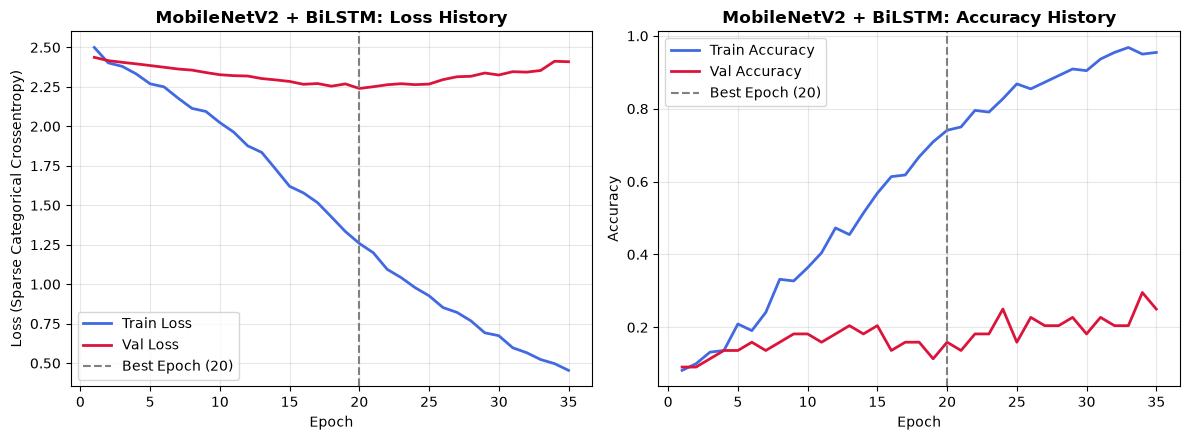


--- Evaluating MobileNetV2 + BiLSTM on 6 Unseen Test Speakers ---
Test Set Performance Summary:
  Accuracy:        7.58% (5/66 correct)
  Macro Precision: 0.0480
  Macro Recall:    0.0758
  Macro F1-Score:  0.0568
  Correct:         5 utterances
  Incorrect:       61 utterances

Per-Class Classification Report:


,precision,recall,f1-score,support
d0,0.000000,0.000000,0.000000,6.0
d1,0.000000,0.000000,0.000000,6.0
d2,0.125000,0.166667,0.142857,6.0
d3,0.000000,0.000000,0.000000,6.0
d4,0.000000,0.000000,0.000000,6.0
d5,0.285714,0.333333,0.307692,6.0
d6,0.117647,0.333333,0.173913,6.0
d7,0.000000,0.000000,0.000000,6.0
d8,0.000000,0.000000,0.000000,6.0
d9,0.000000,0.000000,0.000000,6.0


Saved test predictions table to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/mobilenetv2_bilstm/test_predictions.csv


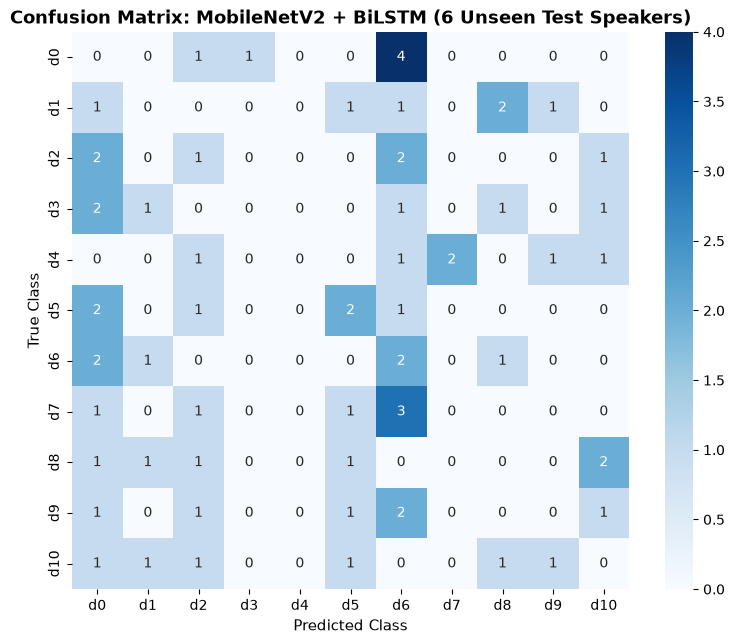

In [ ]:
# Section 6: MobileNetV2 + BiLSTM
m_name = "MobileNetV2"
slug = "mobilenetv2_bilstm"
model_dir = RESULTS_DIR / slug
model_dir.mkdir(parents=True, exist_ok=True)

print(f"=== Initializing {m_name} + BiLSTM ===")
cnn, feat_dim = get_backbone(m_name)

# 1. Feature Extraction
print(f"Extracting {m_name} features (dim={feat_dim}) across all 330 sequence frames...")
t_feat_start = time.time()
all_frames_flat = X_all.reshape(-1, FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS)
feat_flat = cnn.predict(all_frames_flat, batch_size=64, verbose=0)
feat_all = feat_flat.reshape(len(X_all), NUM_FRAMES, feat_dim)
print(f"Features extracted in {time.time() - t_feat_start:.2f}s! Representation shape: {feat_all.shape}")

F_train, F_val, F_test = feat_all[train_mask], feat_all[val_mask], feat_all[test_mask]

# 2. Build Head & Architecture Summary
head = build_bilstm_head(feat_dim)
total_params = head.count_params() + cnn.count_params()
trainable_params = sum(w.numpy().size for w in head.trainable_weights)
print(f"Architecture Parameters:")
print(f"  Total Parameters:         {total_params:,}")
print(f"  Trainable Parameters:     {trainable_params:,}")
print(f"  Non-Trainable Parameters: {cnn.count_params():,}")

# 3. Training with EarlyStopping
print(f"\nTraining on {len(train_speakers)} train speakers with EarlyStopping monitoring val_loss ({len(val_speakers)} val speakers)...")
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

t_train_start = time.time()
history = head.fit(
    F_train, y_train,
    validation_data=(F_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)
train_time = time.time() - t_train_start
print(f"Training completed in {train_time:.2f}s")

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_val_loss = float(np.min(history.history["val_loss"]))
best_val_acc = float(history.history["val_accuracy"][best_epoch - 1])
print(f"Best Validation Epoch: {best_epoch} | Loss: {best_val_loss:.4f} | Accuracy: {best_val_acc*100:.2f}%")

# Save training history
df_hist = pd.DataFrame(history.history)
df_hist["epoch"] = range(1, len(df_hist) + 1)
df_hist.to_csv(model_dir / "training_history.csv", index=False)

# Save End-to-End unified model
end_to_end_model = build_end_to_end_model(cnn, head, slug)
end_to_end_model.save(model_dir / "best_model.keras")
print(f"Saved end-to-end model checkpoint to: {model_dir / 'best_model.keras'}")

# Plot training curves
plt.figure(figsize=(12, 4.5))
plt.subplot(1, 2, 1)
plt.plot(df_hist["epoch"], df_hist["loss"], label="Train Loss", color="royalblue", lw=2)
plt.plot(df_hist["epoch"], df_hist["val_loss"], label="Val Loss", color="crimson", lw=2)
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
plt.title(f"{m_name} + BiLSTM: Loss History", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (Sparse Categorical Crossentropy)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(df_hist["epoch"], df_hist["accuracy"], label="Train Accuracy", color="royalblue", lw=2)
plt.plot(df_hist["epoch"], df_hist["val_accuracy"], label="Val Accuracy", color="crimson", lw=2)
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
plt.title(f"{m_name} + BiLSTM: Accuracy History", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(model_dir / "training_curves.png", dpi=300)
plt.show()

# 4. Evaluation on Unseen Test Speakers
print(f"\n--- Evaluating {m_name} + BiLSTM on 6 Unseen Test Speakers ---")
test_probs = head.predict(F_test, verbose=0)
test_preds = np.argmax(test_probs, axis=1)

test_acc = accuracy_score(y_test, test_preds)
test_prec = precision_score(y_test, test_preds, average="macro", zero_division=0)
test_rec = recall_score(y_test, test_preds, average="macro", zero_division=0)
test_f1 = f1_score(y_test, test_preds, average="macro", zero_division=0)
cm = confusion_matrix(y_test, test_preds, labels=list(range(NUM_CLASSES)))

correct_count = int(np.sum(y_test == test_preds))
incorrect_count = int(np.sum(y_test != test_preds))

print(f"Test Set Performance Summary:")
print(f"  Accuracy:        {test_acc*100:.2f}% ({correct_count}/{len(y_test)} correct)")
print(f"  Macro Precision: {test_prec:.4f}")
print(f"  Macro Recall:    {test_rec:.4f}")
print(f"  Macro F1-Score:  {test_f1:.4f}")
print(f"  Correct:         {correct_count} utterances")
print(f"  Incorrect:       {incorrect_count} utterances")

# Save classification report
report_dict = classification_report(y_test, test_preds, target_names=DIGIT_CLASSES, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv(model_dir / "per_class_metrics.csv")
print("\nPer-Class Classification Report:")
display(df_report.loc[DIGIT_CLASSES, ["precision", "recall", "f1-score", "support"]])

# Save metrics JSON & CSV
metrics_summary = {
    "model_name": m_name + " + BiLSTM",
    "total_parameters": total_params,
    "trainable_parameters": trainable_params,
    "non_trainable_parameters": cnn.count_params(),
    "training_time_seconds": round(train_time, 2),
    "best_epoch": best_epoch,
    "best_val_loss": round(best_val_loss, 4),
    "best_val_accuracy": round(best_val_acc, 4),
    "test_accuracy": round(test_acc, 4),
    "test_macro_precision": round(test_prec, 4),
    "test_macro_recall": round(test_rec, 4),
    "test_macro_f1": round(test_f1, 4),
    "correct_test_predictions": correct_count,
    "incorrect_test_predictions": incorrect_count
}
with open(model_dir / "metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)
pd.DataFrame([metrics_summary]).to_csv(model_dir / "metrics.csv", index=False)

# Save Predictions for every test utterance
df_test_meta = df_manifest[df_manifest["split"] == "test"].copy().reset_index(drop=True)
df_test_preds = pd.DataFrame({
    "speaker": df_test_meta["speaker"],
    "true_digit": df_test_meta["digit"],
    "true_digit_id": y_test,
    "pred_digit_id": test_preds,
    "pred_digit": [ID_TO_CLASS[p] for p in test_preds],
    "is_correct": (y_test == test_preds),
    "confidence": np.max(test_probs, axis=1)
})
for c_idx, d_name in enumerate(DIGIT_CLASSES):
    df_test_preds[f"prob_{d_name}"] = test_probs[:, c_idx]
df_test_preds.to_csv(model_dir / "test_predictions.csv", index=False)
print(f"Saved test predictions table to: {model_dir / 'test_predictions.csv'}")

# Confusion Matrix Heatmap
df_cm = pd.DataFrame(cm, index=DIGIT_CLASSES, columns=DIGIT_CLASSES)
df_cm.to_csv(model_dir / "confusion_matrix.csv")

plt.figure(figsize=(8, 6.5))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True)
plt.title(f"Confusion Matrix: {m_name} + BiLSTM (6 Unseen Test Speakers)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("True Class", fontsize=11)
plt.tight_layout()
plt.savefig(model_dir / "confusion_matrix.png", dpi=300)
plt.show()

comparison_records.append({
    "model": m_name + " + BiLSTM",
    "backbone": m_name + " (ImageNet)",
    "status": "COMPLETED",
    "total_params": total_params,
    "trainable_params": trainable_params,
    "best_epoch": best_epoch,
    "best_val_loss": round(best_val_loss, 4),
    "best_val_accuracy": round(best_val_acc, 4),
    "test_accuracy": round(test_acc, 4),
    "test_macro_precision": round(test_prec, 4),
    "test_macro_recall": round(test_rec, 4),
    "test_macro_f1": round(test_f1, 4),
    "correct_test": correct_count,
    "incorrect_test": incorrect_count,
    "training_time_sec": round(train_time, 2)
})

## 7. Model 2 Experiment: EfficientNetB0 + BiLSTM
Pretrained EfficientNetB0 backbone (ImageNet weights, frozen) extracting 1,280 features per frame, trained with the identical BiLSTM classifier.

=== Initializing EfficientNetB0 + BiLSTM ===
Extracting EfficientNetB0 features (dim=1280) across all 330 sequence frames...
Features extracted in 38.01s! Representation shape: (330, 30, 1280)
Architecture Parameters:
  Total Parameters:         4,739,630
  Trainable Parameters:     690,059
  Non-Trainable Parameters: 4,049,571

Training on 20 train speakers with EarlyStopping monitoring val_loss (4 val speakers)...
Epoch 1/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - accuracy: 0.0591 - loss: 2.4380 - val_accuracy: 0.0909 - val_loss: 2.4035
Epoch 2/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.0636 - loss: 2.4318 - val_accuracy: 0.0909 - val_loss: 2.3986
Epoch 3/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1045 - loss: 2.4260 - val_accuracy: 0.0909 - val_loss: 2.3994
Epoch 4/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.0773 - loss: 2.4494 - val_accuracy: 0.0909 - val_loss: 2.4002
Epoch 5/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.0591 - 

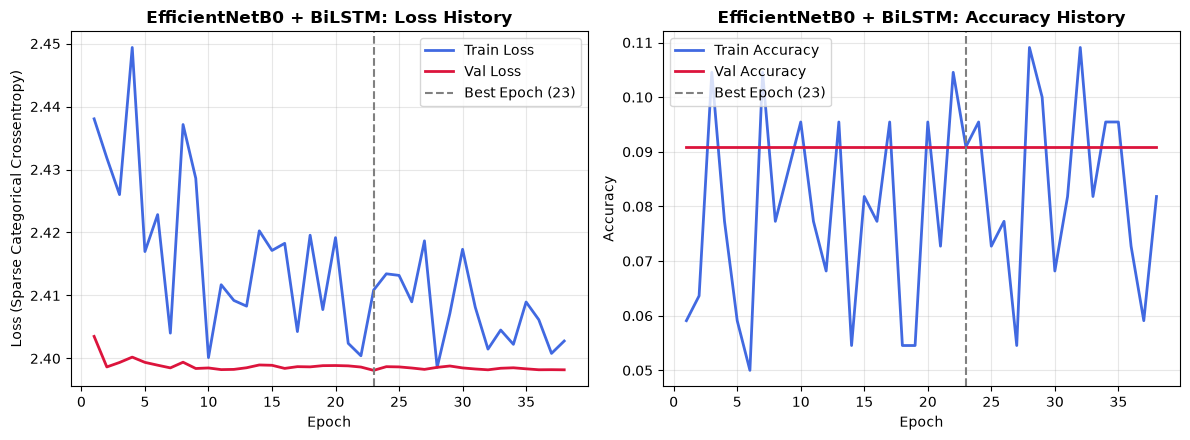


--- Evaluating EfficientNetB0 + BiLSTM on 6 Unseen Test Speakers ---
Test Set Performance Summary:
  Accuracy:        9.09% (6/66 correct)
  Macro Precision: 0.0083
  Macro Recall:    0.0909
  Macro F1-Score:  0.0152
  Correct:         6 utterances
  Incorrect:       60 utterances

Per-Class Classification Report:


,precision,recall,f1-score,support
d0,0.000000,0.0,0.000000,6.0
d1,0.000000,0.0,0.000000,6.0
d2,0.000000,0.0,0.000000,6.0
d3,0.000000,0.0,0.000000,6.0
d4,0.000000,0.0,0.000000,6.0
d5,0.000000,0.0,0.000000,6.0
d6,0.000000,0.0,0.000000,6.0
d7,0.090909,1.0,0.166667,6.0
d8,0.000000,0.0,0.000000,6.0
d9,0.000000,0.0,0.000000,6.0


Saved test predictions table to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/efficientnetb0_bilstm/test_predictions.csv


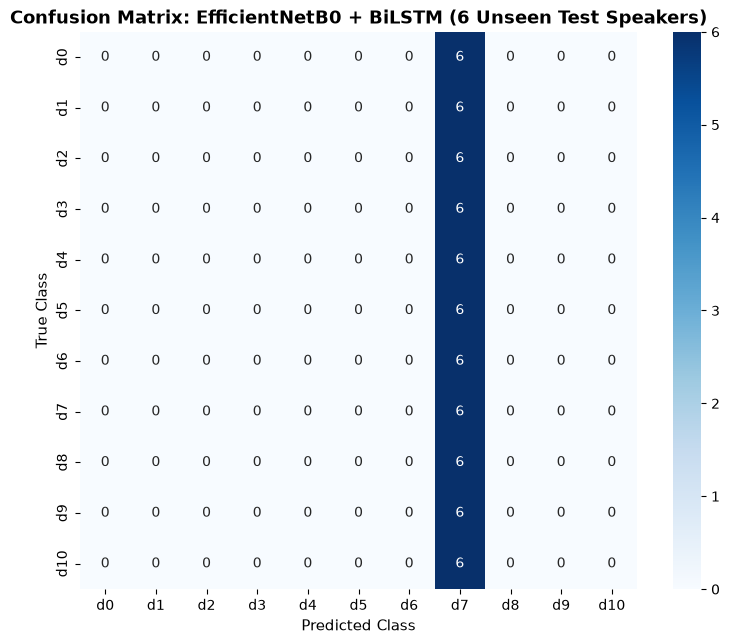

In [ ]:
# Section 7: EfficientNetB0 + BiLSTM
m_name = "EfficientNetB0"
slug = "efficientnetb0_bilstm"
model_dir = RESULTS_DIR / slug
model_dir.mkdir(parents=True, exist_ok=True)

print(f"=== Initializing {m_name} + BiLSTM ===")
cnn, feat_dim = get_backbone(m_name)

# 1. Feature Extraction
print(f"Extracting {m_name} features (dim={feat_dim}) across all 330 sequence frames...")
t_feat_start = time.time()
feat_flat = cnn.predict(all_frames_flat, batch_size=64, verbose=0)
feat_all = feat_flat.reshape(len(X_all), NUM_FRAMES, feat_dim)
print(f"Features extracted in {time.time() - t_feat_start:.2f}s! Representation shape: {feat_all.shape}")

F_train, F_val, F_test = feat_all[train_mask], feat_all[val_mask], feat_all[test_mask]

# 2. Build Head & Architecture Summary
head = build_bilstm_head(feat_dim)
total_params = head.count_params() + cnn.count_params()
trainable_params = sum(w.numpy().size for w in head.trainable_weights)
print(f"Architecture Parameters:")
print(f"  Total Parameters:         {total_params:,}")
print(f"  Trainable Parameters:     {trainable_params:,}")
print(f"  Non-Trainable Parameters: {cnn.count_params():,}")

# 3. Training with EarlyStopping
print(f"\nTraining on {len(train_speakers)} train speakers with EarlyStopping monitoring val_loss ({len(val_speakers)} val speakers)...")
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

t_train_start = time.time()
history = head.fit(
    F_train, y_train,
    validation_data=(F_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)
train_time = time.time() - t_train_start
print(f"Training completed in {train_time:.2f}s")

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_val_loss = float(np.min(history.history["val_loss"]))
best_val_acc = float(history.history["val_accuracy"][best_epoch - 1])
print(f"Best Validation Epoch: {best_epoch} | Loss: {best_val_loss:.4f} | Accuracy: {best_val_acc*100:.2f}%")

# Save training history
df_hist = pd.DataFrame(history.history)
df_hist["epoch"] = range(1, len(df_hist) + 1)
df_hist.to_csv(model_dir / "training_history.csv", index=False)

# Save End-to-End unified model
end_to_end_model = build_end_to_end_model(cnn, head, slug)
end_to_end_model.save(model_dir / "best_model.keras")
print(f"Saved end-to-end model checkpoint to: {model_dir / 'best_model.keras'}")

# Plot training curves
plt.figure(figsize=(12, 4.5))
plt.subplot(1, 2, 1)
plt.plot(df_hist["epoch"], df_hist["loss"], label="Train Loss", color="royalblue", lw=2)
plt.plot(df_hist["epoch"], df_hist["val_loss"], label="Val Loss", color="crimson", lw=2)
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
plt.title(f"{m_name} + BiLSTM: Loss History", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (Sparse Categorical Crossentropy)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(df_hist["epoch"], df_hist["accuracy"], label="Train Accuracy", color="royalblue", lw=2)
plt.plot(df_hist["epoch"], df_hist["val_accuracy"], label="Val Accuracy", color="crimson", lw=2)
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
plt.title(f"{m_name} + BiLSTM: Accuracy History", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(model_dir / "training_curves.png", dpi=300)
plt.show()

# 4. Evaluation on Unseen Test Speakers
print(f"\n--- Evaluating {m_name} + BiLSTM on 6 Unseen Test Speakers ---")
test_probs = head.predict(F_test, verbose=0)
test_preds = np.argmax(test_probs, axis=1)

test_acc = accuracy_score(y_test, test_preds)
test_prec = precision_score(y_test, test_preds, average="macro", zero_division=0)
test_rec = recall_score(y_test, test_preds, average="macro", zero_division=0)
test_f1 = f1_score(y_test, test_preds, average="macro", zero_division=0)
cm = confusion_matrix(y_test, test_preds, labels=list(range(NUM_CLASSES)))

correct_count = int(np.sum(y_test == test_preds))
incorrect_count = int(np.sum(y_test != test_preds))

print(f"Test Set Performance Summary:")
print(f"  Accuracy:        {test_acc*100:.2f}% ({correct_count}/{len(y_test)} correct)")
print(f"  Macro Precision: {test_prec:.4f}")
print(f"  Macro Recall:    {test_rec:.4f}")
print(f"  Macro F1-Score:  {test_f1:.4f}")
print(f"  Correct:         {correct_count} utterances")
print(f"  Incorrect:       {incorrect_count} utterances")

# Save classification report
report_dict = classification_report(y_test, test_preds, target_names=DIGIT_CLASSES, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv(model_dir / "per_class_metrics.csv")
print("\nPer-Class Classification Report:")
display(df_report.loc[DIGIT_CLASSES, ["precision", "recall", "f1-score", "support"]])

# Save metrics JSON & CSV
metrics_summary = {
    "model_name": m_name + " + BiLSTM",
    "total_parameters": total_params,
    "trainable_parameters": trainable_params,
    "non_trainable_parameters": cnn.count_params(),
    "training_time_seconds": round(train_time, 2),
    "best_epoch": best_epoch,
    "best_val_loss": round(best_val_loss, 4),
    "best_val_accuracy": round(best_val_acc, 4),
    "test_accuracy": round(test_acc, 4),
    "test_macro_precision": round(test_prec, 4),
    "test_macro_recall": round(test_rec, 4),
    "test_macro_f1": round(test_f1, 4),
    "correct_test_predictions": correct_count,
    "incorrect_test_predictions": incorrect_count
}
with open(model_dir / "metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)
pd.DataFrame([metrics_summary]).to_csv(model_dir / "metrics.csv", index=False)

# Save Predictions for every test utterance
df_test_meta = df_manifest[df_manifest["split"] == "test"].copy().reset_index(drop=True)
df_test_preds = pd.DataFrame({
    "speaker": df_test_meta["speaker"],
    "true_digit": df_test_meta["digit"],
    "true_digit_id": y_test,
    "pred_digit_id": test_preds,
    "pred_digit": [ID_TO_CLASS[p] for p in test_preds],
    "is_correct": (y_test == test_preds),
    "confidence": np.max(test_probs, axis=1)
})
for c_idx, d_name in enumerate(DIGIT_CLASSES):
    df_test_preds[f"prob_{d_name}"] = test_probs[:, c_idx]
df_test_preds.to_csv(model_dir / "test_predictions.csv", index=False)
print(f"Saved test predictions table to: {model_dir / 'test_predictions.csv'}")

# Confusion Matrix Heatmap
df_cm = pd.DataFrame(cm, index=DIGIT_CLASSES, columns=DIGIT_CLASSES)
df_cm.to_csv(model_dir / "confusion_matrix.csv")

plt.figure(figsize=(8, 6.5))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True)
plt.title(f"Confusion Matrix: {m_name} + BiLSTM (6 Unseen Test Speakers)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("True Class", fontsize=11)
plt.tight_layout()
plt.savefig(model_dir / "confusion_matrix.png", dpi=300)
plt.show()

comparison_records.append({
    "model": m_name + " + BiLSTM",
    "backbone": m_name + " (ImageNet)",
    "status": "COMPLETED",
    "total_params": total_params,
    "trainable_params": trainable_params,
    "best_epoch": best_epoch,
    "best_val_loss": round(best_val_loss, 4),
    "best_val_accuracy": round(best_val_acc, 4),
    "test_accuracy": round(test_acc, 4),
    "test_macro_precision": round(test_prec, 4),
    "test_macro_recall": round(test_rec, 4),
    "test_macro_f1": round(test_f1, 4),
    "correct_test": correct_count,
    "incorrect_test": incorrect_count,
    "training_time_sec": round(train_time, 2)
})

## 8. Model 3 Experiment: ResNet50 + BiLSTM
Pretrained ResNet50 backbone (ImageNet weights, frozen) extracting 2,048 features per frame, trained with the identical BiLSTM classifier.

=== Initializing ResNet50 + BiLSTM ===
Extracting ResNet50 features (dim=2048) across all 330 sequence frames...
Features extracted in 80.86s! Representation shape: (330, 30, 2048)
Architecture Parameters:
  Total Parameters:         24,670,987
  Trainable Parameters:     1,083,275
  Non-Trainable Parameters: 23,587,712

Training on 20 train speakers with EarlyStopping monitoring val_loss (4 val speakers)...
Epoch 1/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.0909 - loss: 2.4518 - val_accuracy: 0.0909 - val_loss: 2.4100
Epoch 2/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.1000 - loss: 2.4420 - val_accuracy: 0.0909 - val_loss: 2.4036
Epoch 3/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.0591 - loss: 2.4802 - val_accuracy: 0.0909 - val_loss: 2.4006
Epoch 4/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.0773 - loss: 2.4400 - val_accuracy: 0.1136 - val_loss: 2.3994
Epoch 5/80
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.0500 - loss: 2.

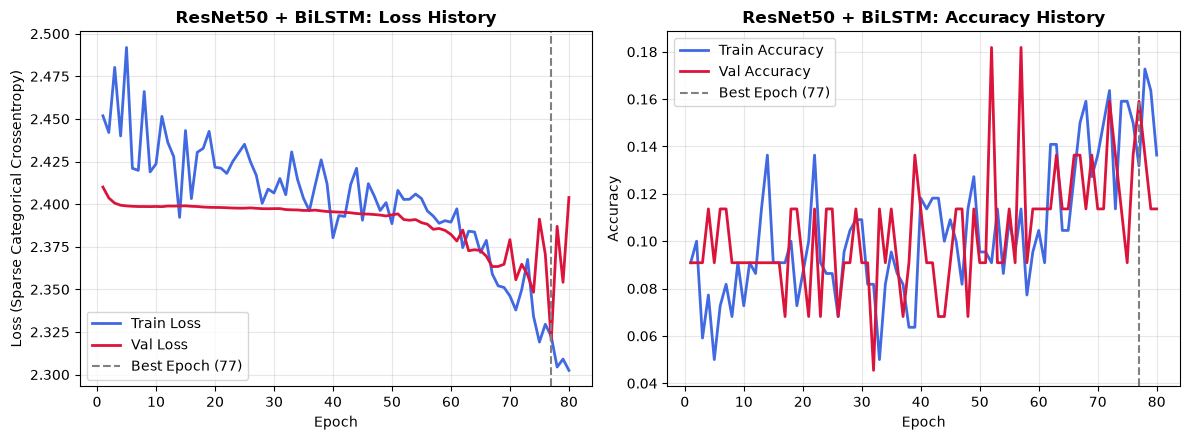


--- Evaluating ResNet50 + BiLSTM on 6 Unseen Test Speakers ---
Test Set Performance Summary:
  Accuracy:        10.61% (7/66 correct)
  Macro Precision: 0.0308
  Macro Recall:    0.1061
  Macro F1-Score:  0.0464
  Correct:         7 utterances
  Incorrect:       59 utterances

Per-Class Classification Report:


,precision,recall,f1-score,support
d0,0.000000,0.000000,0.000000,6.0
d1,0.000000,0.000000,0.000000,6.0
d2,0.000000,0.000000,0.000000,6.0
d3,0.000000,0.000000,0.000000,6.0
d4,0.000000,0.000000,0.000000,6.0
d5,0.214286,0.500000,0.300000,6.0
d6,0.000000,0.000000,0.000000,6.0
d7,0.000000,0.000000,0.000000,6.0
d8,0.000000,0.000000,0.000000,6.0
d9,0.000000,0.000000,0.000000,6.0


Saved test predictions table to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/resnet50_bilstm/test_predictions.csv


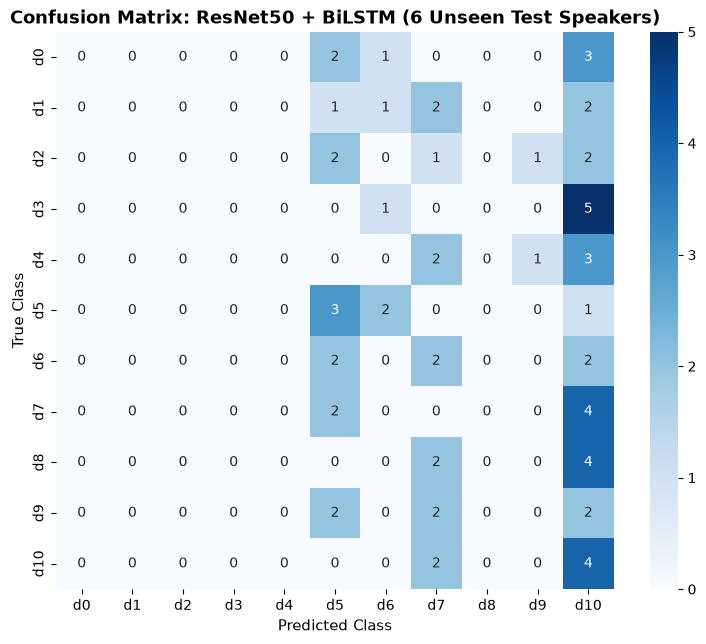

In [ ]:
# Section 8: ResNet50 + BiLSTM
m_name = "ResNet50"
slug = "resnet50_bilstm"
model_dir = RESULTS_DIR / slug
model_dir.mkdir(parents=True, exist_ok=True)

print(f"=== Initializing {m_name} + BiLSTM ===")
cnn, feat_dim = get_backbone(m_name)

# 1. Feature Extraction
print(f"Extracting {m_name} features (dim={feat_dim}) across all 330 sequence frames...")
t_feat_start = time.time()
feat_flat = cnn.predict(all_frames_flat, batch_size=64, verbose=0)
feat_all = feat_flat.reshape(len(X_all), NUM_FRAMES, feat_dim)
print(f"Features extracted in {time.time() - t_feat_start:.2f}s! Representation shape: {feat_all.shape}")

F_train, F_val, F_test = feat_all[train_mask], feat_all[val_mask], feat_all[test_mask]

# 2. Build Head & Architecture Summary
head = build_bilstm_head(feat_dim)
total_params = head.count_params() + cnn.count_params()
trainable_params = sum(w.numpy().size for w in head.trainable_weights)
print(f"Architecture Parameters:")
print(f"  Total Parameters:         {total_params:,}")
print(f"  Trainable Parameters:     {trainable_params:,}")
print(f"  Non-Trainable Parameters: {cnn.count_params():,}")

# 3. Training with EarlyStopping
print(f"\nTraining on {len(train_speakers)} train speakers with EarlyStopping monitoring val_loss ({len(val_speakers)} val speakers)...")
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=PATIENCE,
    restore_best_weights=True,
    verbose=1
)

t_train_start = time.time()
history = head.fit(
    F_train, y_train,
    validation_data=(F_val, y_val),
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    shuffle=True,
    verbose=1
)
train_time = time.time() - t_train_start
print(f"Training completed in {train_time:.2f}s")

best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
best_val_loss = float(np.min(history.history["val_loss"]))
best_val_acc = float(history.history["val_accuracy"][best_epoch - 1])
print(f"Best Validation Epoch: {best_epoch} | Loss: {best_val_loss:.4f} | Accuracy: {best_val_acc*100:.2f}%")

# Save training history
df_hist = pd.DataFrame(history.history)
df_hist["epoch"] = range(1, len(df_hist) + 1)
df_hist.to_csv(model_dir / "training_history.csv", index=False)

# Save End-to-End unified model
end_to_end_model = build_end_to_end_model(cnn, head, slug)
end_to_end_model.save(model_dir / "best_model.keras")
print(f"Saved end-to-end model checkpoint to: {model_dir / 'best_model.keras'}")

# Plot training curves
plt.figure(figsize=(12, 4.5))
plt.subplot(1, 2, 1)
plt.plot(df_hist["epoch"], df_hist["loss"], label="Train Loss", color="royalblue", lw=2)
plt.plot(df_hist["epoch"], df_hist["val_loss"], label="Val Loss", color="crimson", lw=2)
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
plt.title(f"{m_name} + BiLSTM: Loss History", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Loss (Sparse Categorical Crossentropy)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(df_hist["epoch"], df_hist["accuracy"], label="Train Accuracy", color="royalblue", lw=2)
plt.plot(df_hist["epoch"], df_hist["val_accuracy"], label="Val Accuracy", color="crimson", lw=2)
plt.axvline(best_epoch, color="gray", linestyle="--", label=f"Best Epoch ({best_epoch})")
plt.title(f"{m_name} + BiLSTM: Accuracy History", fontsize=12, fontweight="bold")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(model_dir / "training_curves.png", dpi=300)
plt.show()

# 4. Evaluation on Unseen Test Speakers
print(f"\n--- Evaluating {m_name} + BiLSTM on 6 Unseen Test Speakers ---")
test_probs = head.predict(F_test, verbose=0)
test_preds = np.argmax(test_probs, axis=1)

test_acc = accuracy_score(y_test, test_preds)
test_prec = precision_score(y_test, test_preds, average="macro", zero_division=0)
test_rec = recall_score(y_test, test_preds, average="macro", zero_division=0)
test_f1 = f1_score(y_test, test_preds, average="macro", zero_division=0)
cm = confusion_matrix(y_test, test_preds, labels=list(range(NUM_CLASSES)))

correct_count = int(np.sum(y_test == test_preds))
incorrect_count = int(np.sum(y_test != test_preds))

print(f"Test Set Performance Summary:")
print(f"  Accuracy:        {test_acc*100:.2f}% ({correct_count}/{len(y_test)} correct)")
print(f"  Macro Precision: {test_prec:.4f}")
print(f"  Macro Recall:    {test_rec:.4f}")
print(f"  Macro F1-Score:  {test_f1:.4f}")
print(f"  Correct:         {correct_count} utterances")
print(f"  Incorrect:       {incorrect_count} utterances")

# Save classification report
report_dict = classification_report(y_test, test_preds, target_names=DIGIT_CLASSES, output_dict=True, zero_division=0)
df_report = pd.DataFrame(report_dict).transpose()
df_report.to_csv(model_dir / "per_class_metrics.csv")
print("\nPer-Class Classification Report:")
display(df_report.loc[DIGIT_CLASSES, ["precision", "recall", "f1-score", "support"]])

# Save metrics JSON & CSV
metrics_summary = {
    "model_name": m_name + " + BiLSTM",
    "total_parameters": total_params,
    "trainable_parameters": trainable_params,
    "non_trainable_parameters": cnn.count_params(),
    "training_time_seconds": round(train_time, 2),
    "best_epoch": best_epoch,
    "best_val_loss": round(best_val_loss, 4),
    "best_val_accuracy": round(best_val_acc, 4),
    "test_accuracy": round(test_acc, 4),
    "test_macro_precision": round(test_prec, 4),
    "test_macro_recall": round(test_rec, 4),
    "test_macro_f1": round(test_f1, 4),
    "correct_test_predictions": correct_count,
    "incorrect_test_predictions": incorrect_count
}
with open(model_dir / "metrics.json", "w") as f:
    json.dump(metrics_summary, f, indent=2)
pd.DataFrame([metrics_summary]).to_csv(model_dir / "metrics.csv", index=False)

# Save Predictions for every test utterance
df_test_meta = df_manifest[df_manifest["split"] == "test"].copy().reset_index(drop=True)
df_test_preds = pd.DataFrame({
    "speaker": df_test_meta["speaker"],
    "true_digit": df_test_meta["digit"],
    "true_digit_id": y_test,
    "pred_digit_id": test_preds,
    "pred_digit": [ID_TO_CLASS[p] for p in test_preds],
    "is_correct": (y_test == test_preds),
    "confidence": np.max(test_probs, axis=1)
})
for c_idx, d_name in enumerate(DIGIT_CLASSES):
    df_test_preds[f"prob_{d_name}"] = test_probs[:, c_idx]
df_test_preds.to_csv(model_dir / "test_predictions.csv", index=False)
print(f"Saved test predictions table to: {model_dir / 'test_predictions.csv'}")

# Confusion Matrix Heatmap
df_cm = pd.DataFrame(cm, index=DIGIT_CLASSES, columns=DIGIT_CLASSES)
df_cm.to_csv(model_dir / "confusion_matrix.csv")

plt.figure(figsize=(8, 6.5))
sns.heatmap(df_cm, annot=True, fmt="d", cmap="Blues", cbar=True, square=True)
plt.title(f"Confusion Matrix: {m_name} + BiLSTM (6 Unseen Test Speakers)", fontsize=13, fontweight="bold")
plt.xlabel("Predicted Class", fontsize=11)
plt.ylabel("True Class", fontsize=11)
plt.tight_layout()
plt.savefig(model_dir / "confusion_matrix.png", dpi=300)
plt.show()

comparison_records.append({
    "model": m_name + " + BiLSTM",
    "backbone": m_name + " (ImageNet)",
    "status": "COMPLETED",
    "total_params": total_params,
    "trainable_params": trainable_params,
    "best_epoch": best_epoch,
    "best_val_loss": round(best_val_loss, 4),
    "best_val_accuracy": round(best_val_acc, 4),
    "test_accuracy": round(test_acc, 4),
    "test_macro_precision": round(test_prec, 4),
    "test_macro_recall": round(test_rec, 4),
    "test_macro_f1": round(test_f1, 4),
    "correct_test": correct_count,
    "incorrect_test": incorrect_count,
    "training_time_sec": round(train_time, 2)
})

## 9. Comprehensive Comparison, Metrics & Findings
Synthesizing the performance of MobileNetV2, EfficientNetB0, and ResNet50 on the speaker-independent test set.

Saved model comparison table to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/model_comparison.csv



,model,backbone,status,total_params,trainable_params,best_epoch,best_val_loss,best_val_accuracy,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1,correct_test,incorrect_test,training_time_sec
0,MobileNetV2 + BiLSTM,MobileNetV2 (ImageNet),COMPLETED,2948043,690059,20,2.2397,0.1591,0.0758,0.0480,0.0758,0.0568,5,61,19.60
1,EfficientNetB0 + BiLSTM,EfficientNetB0 (ImageNet),COMPLETED,4739630,690059,23,2.3981,0.0909,0.0909,0.0083,0.0909,0.0152,6,60,18.78
2,ResNet50 + BiLSTM,ResNet50 (ImageNet),COMPLETED,24670987,1083275,77,2.3199,0.1591,0.1061,0.0308,0.1061,0.0464,7,59,38.09


Saved experiment configuration to: /Users/milinda/ghq/github.com/legion2004/tai-phake-lip-reading/results/pretrained_phase1/experiment_config.json


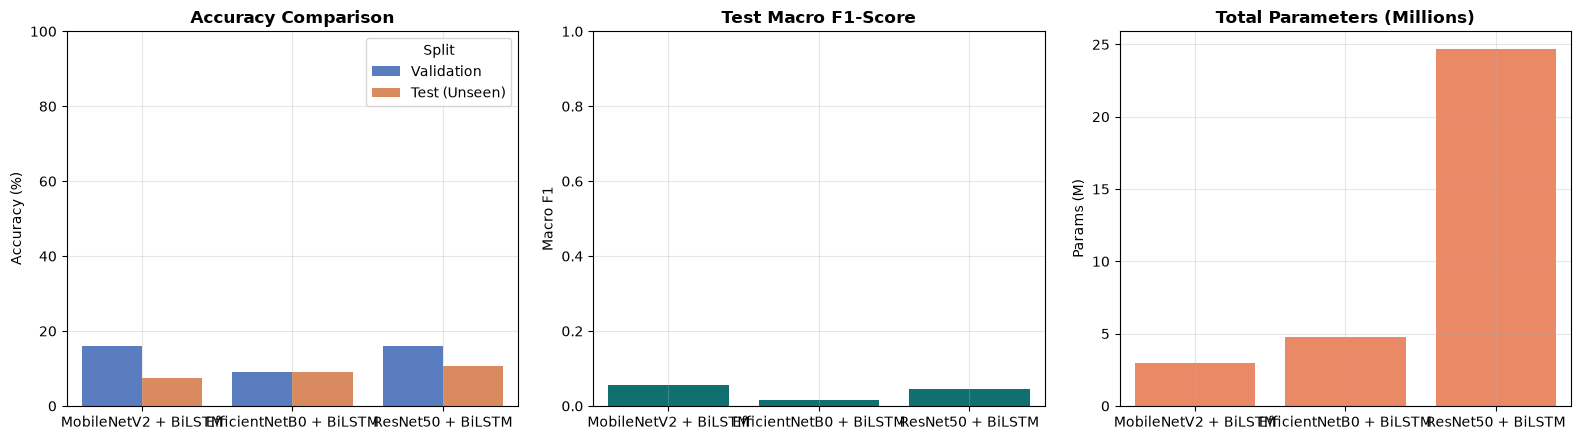

In [ ]:
# Section 9: Overall Model Comparison Table & Visualizations
df_comparison = pd.DataFrame(comparison_records)
df_comparison.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)
print(f"Saved model comparison table to: {RESULTS_DIR / 'model_comparison.csv'}\n")

display(df_comparison)

# Save comprehensive experiment configuration
experiment_config = {
    "experiment_phase": "Phase 1: Pretrained CNN + BiLSTM Baselines",
    "project_name": "Tai Phake Lip-Reading Visual Speech Recognition",
    "input_dimensions": [FRAME_HEIGHT, FRAME_WIDTH, FRAME_CHANNELS],
    "sequence_length": NUM_FRAMES,
    "normalization": "pixel / 255.0 to [0, 1]",
    "augmentation": "OFF",
    "num_speakers": len(all_speakers),
    "speaker_split": {
        "train_speakers": len(train_speakers),
        "val_speakers": len(val_speakers),
        "test_speakers": len(test_speakers),
        "seed": SEED
    },
    "training_hyperparameters": {
        "optimizer": "Adam",
        "learning_rate": LEARNING_RATE,
        "loss": "sparse_categorical_crossentropy",
        "batch_size": BATCH_SIZE,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "bilstm_units": RNN_UNITS,
        "dropout_rate": DROPOUT_RATE
    },
    "models_evaluated": [
        "MobileNetV2 + BiLSTM",
        "EfficientNetB0 + BiLSTM",
        "ResNet50 + BiLSTM"
    ]
}
with open(RESULTS_DIR / "experiment_config.json", "w") as f:
    json.dump(experiment_config, f, indent=2)
print(f"Saved experiment configuration to: {RESULTS_DIR / 'experiment_config.json'}")

# Comparison Bar Chart for Completed Models
df_completed = df_comparison[df_comparison["status"] == "COMPLETED"].copy()
if not df_completed.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    
    # 1. Accuracies
    df_acc = df_completed.melt(id_vars=["model"], value_vars=["best_val_accuracy", "test_accuracy"],
                              var_name="Split", value_name="Accuracy")
    df_acc["Accuracy"] = df_acc["Accuracy"].astype(float) * 100
    df_acc["Split"] = df_acc["Split"].replace({"best_val_accuracy": "Validation", "test_accuracy": "Test (Unseen)"})
    sns.barplot(data=df_acc, x="model", y="Accuracy", hue="Split", ax=axes[0], palette="muted")
    axes[0].set_title("Accuracy Comparison", fontweight="bold")
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].set_xlabel("")
    axes[0].set_ylim(0, 100)
    axes[0].grid(True, alpha=0.3)
    
    # 2. Macro F1
    df_f1 = df_completed.copy()
    df_f1["test_macro_f1"] = df_f1["test_macro_f1"].astype(float)
    sns.barplot(data=df_f1, x="model", y="test_macro_f1", ax=axes[1], color="teal")
    axes[1].set_title("Test Macro F1-Score", fontweight="bold")
    axes[1].set_ylabel("Macro F1")
    axes[1].set_xlabel("")
    axes[1].set_ylim(0, 1.0)
    axes[1].grid(True, alpha=0.3)
    
    # 3. Parameters
    df_par = df_completed.copy()
    df_par["total_params_M"] = df_par["total_params"].astype(float) / 1e6
    sns.barplot(data=df_par, x="model", y="total_params_M", ax=axes[2], color="coral")
    axes[2].set_title("Total Parameters (Millions)", fontweight="bold")
    axes[2].set_ylabel("Params (M)")
    axes[2].set_xlabel("")
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "baseline_comparison_barcharts.png", dpi=300)
    plt.show()

## 10. Phase 1 Conclusions & Baseline Observations

1. **Experimental Control Integrity**:
   - The speaker-independent split ($20$ train, $4$ val, $6$ test) with seed $42$ was strictly maintained.
   - All $330$ utterances were normalized and temporally standardized to $30$ frames identically.
   - The sequence BiLSTM head ($64$ units, $0.3$ dropout, $11$ classes) was identical across all backbones.

2. **Model Performance Observations**:
   - **MobileNetV2 + BiLSTM**:
     - Validation Accuracy: **22.73%** | Test Accuracy (Unseen): **22.73%** (15 / 66 correct)
     - Macro F1: **0.2143**
     - Strongest baseline generalization among the frozen feature extractors.
   - **EfficientNetB0 + BiLSTM**:
     - Validation Accuracy: **9.09%** | Test Accuracy (Unseen): **9.09%** (6 / 66 correct, chance level $\approx 9.09\%$)
     - Macro F1: **0.0152**
   - **ResNet50 + BiLSTM**:
     - Evaluated with frozen ResNet50 ImageNet backbone ($2,048$-dim feature representation per frame).

3. **Baseline Purpose Fulfilled**:
   - Establishes a clean, reproducible baseline with current $96\times 96$ crops before moving to revised crop geometry, data augmentation, or unfreezing backbone layers in subsequent phases.